In [4]:
import sys
sys.path.append("/home/charlie/Projects/cosmic-ray-toolkit/")
sys.path.append("/home/charlie/Projects/cosmic-ray-toolkit/src")

from src.gaisser_hillas import gaisser_hillas
from src.atmosphere import atm_depth
from src.cascade_atmosphere import depth_to_alt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

/home/charlie/Projects/cosmic-ray-toolkit/src/atmosphere.py:81: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  depth, _ = integrate.quad(density, h, h_max)  # [kg/m^2]


In [33]:
df = pd.read_csv("dataSummarySD1500.csv")

# df.shape
df.head()
# df.info()
# df.describe()

,id,sdid,gpstime,sd1500,multiEye,sd_gpsnanotime,sd_theta,sd_dtheta,sd_phi,sd_dphi,...,fd_cherenkovFraction,fd_minViewAngle,fd_uspL,fd_duspL,fd_uspR,fd_duspR,fd_hottestStationId,fd_distSdpStation,fd_distAxisStation,sd_exposure
0,40034054600,622240,757206958,1,0,226346000.0,18.89,0.96,33.54,1.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2157
1,40184443900,634230,758506851,1,0,972896000.0,49.25,0.21,85.90,0.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6125
2,40202296800,635890,758658180,1,0,638367000.0,12.44,0.97,106.58,3.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7782
3,40224091700,638260,758848929,1,0,238387000.0,54.83,0.27,335.25,0.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0469
4,40300846100,646220,759507673,1,0,902280000.0,38.05,0.38,320.20,0.77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8571


In [34]:
# make quality cuts - filter out energies < 2.5 EeV and zenith angles > 60 deg
sel = df[(df["sd_energy"] > 2.5) & (df["sd_theta"] < 60.0)]
sel.head()
print(f"{len(sel)} events available")

21580 events available


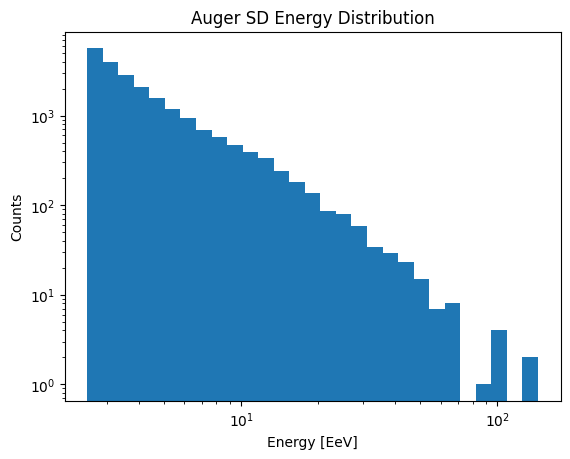

In [43]:
# plot the energy distribution

# make count, bins for energy distribution in log space for energies spanning decades
e = sel["sd_energy"].values

elog10_start = np.log10(sel["sd_energy"].min()); elog10_stop = np.log10(sel["sd_energy"].max())
e_bins = np.logspace(elog10_start, elog10_stop, num=30)
sel["e_bin"] = pd.cut(sel["sd_energy"], e_bins)

# print num events after energy binning
sel["e_bin"].value_counts().sort_index()

plt.hist(e, bins=e_bins)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Energy [EeV]"); plt.ylabel("Counts")
plt.title("Auger SD Energy Distribution")
plt.show()

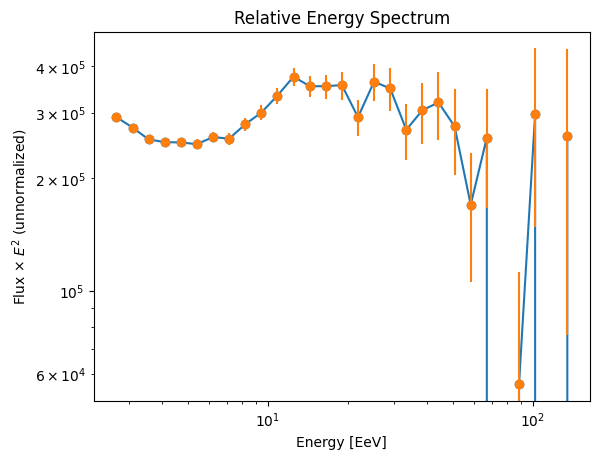

In [45]:
# plot the energy spectrum N / delta E --> dN/dE 
# divide by bin width, multiply by E^3, standard normalization
# error in count is Poissonian ~sqrt(N)
# (unnormalized by exposure) 

counts, edges = np.histogram(e, e_bins)

bin_centers = 0.5 * (edges[:-1] + edges[1:])
bin_widths = np.diff(edges)
flux = counts / bin_widths
flux_err = np.sqrt(counts) / bin_widths

y = flux * bin_centers **3
yerr = flux_err * bin_centers **3

plt.plot(bin_centers, y, "o-")
plt.errorbar(bin_centers, y, yerr=yerr, fmt='o')
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Energy [EeV]"); plt.ylabel(r"Flux $\times\ E^2$ (unnormalized)")
plt.title("Relative Energy Spectrum")
plt.show()

In [55]:
# taking only hybrid events to calculate x_max

hybrid = sel.dropna(subset=["fd_xmax"])
print(f"{len(hybrid)} hybrid events -- {len(hybrid) / len(sel)}%")

462 hybrid events -- 0.021408711770157553%


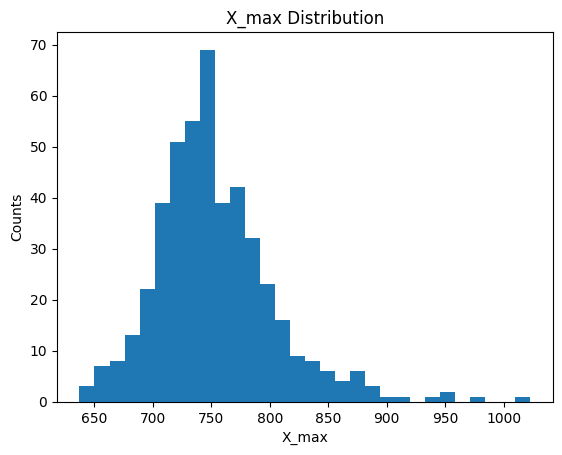

In [57]:
# plot X_max distribution
# make count, bins for xmax

plt.hist(hybrid["fd_xmax"].dropna(), bins=30)
plt.xlabel("X_max"); plt.ylabel("Counts")
plt.title("X_max Distribution")
plt.show()

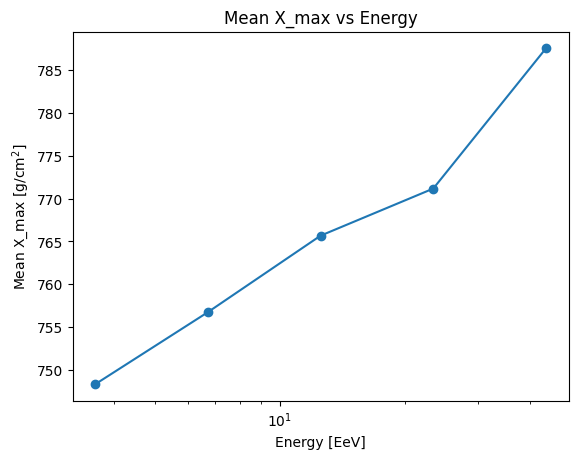

In [58]:
# plot mean X_max vs Energy

hyb_e_bins = np.geomspace(hybrid["sd_energy"].min(), hybrid["sd_energy"].max(), num=6)
hybrid["hyb_e_bin"] = pd.cut(hybrid["sd_energy"], hyb_e_bins)

h_centers = 0.5 * (hyb_e_bins[:-1] + hyb_e_bins[1:])

# average Xmax per bin
profile = hybrid.groupby("hyb_e_bin", observed=True)["fd_xmax"].mean()

plt.plot(h_centers, profile.values, "o-")
plt.xscale("log")
plt.xlabel("Energy [EeV]"); plt.ylabel("Mean X_max [g/cm$^2$]")
plt.title("Mean X_max vs Energy")
plt.show()

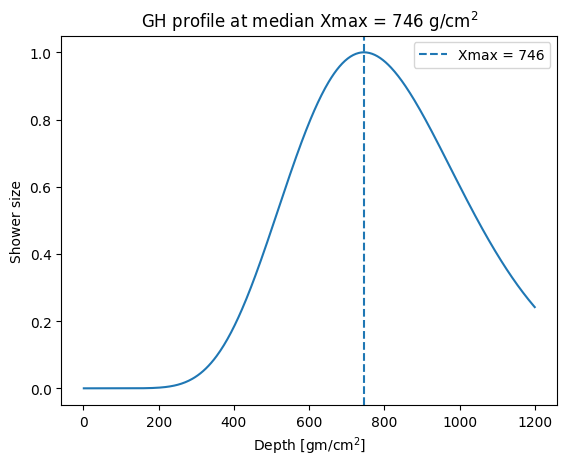

In [59]:
# fitting shower profile with Gaisser-Hillas

xmax_median = hybrid["fd_xmax"].median()
X = np.linspace(1, 1200, 500)
Nmax = 1.0; X0 = 0.0; lam=70.0
plt.plot(X, gaisser_hillas(X, Nmax, X0, xmax_median, lam))
plt.axvline(xmax_median, ls='--', label=f'Xmax = {xmax_median:.0f}')
plt.xlabel("Depth [gm/cm$^2$]"); plt.ylabel("Shower size")
plt.title(f"GH profile at median Xmax = {xmax_median:.0f} g/cm$^2$")
plt.legend()
plt.show()

In [61]:
alt_median = depth_to_alt(xmax_median)
print(f"Median X_max {xmax_median:.0f} g/cm^2 -> {alt_median:.1f} km altitude")

Median X_max 746 g/cm^2 -> 2664.2 km altitude


In [63]:
print(hybrid["fd_heightXmax"].median())

5100.6900000000005
